# Importing required Libraries

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataa

In [2]:
data = pd.read_csv("../Datasets/Thyroid_Diff.csv")
data

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


# Encoding the Labels

In [3]:
encoder = LabelEncoder()
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])

data    

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,11,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0
1,18,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1,0
2,14,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
3,46,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
4,46,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,56,1,1,1,1,2,4,5,3,1,0,6,2,1,4,0,1
379,63,1,1,0,1,2,1,1,3,0,0,6,2,1,4,3,1
380,56,1,1,1,0,2,1,0,3,0,0,6,2,1,4,3,1
381,45,1,1,1,1,0,1,1,1,0,0,6,2,0,3,3,1


# Seperating the data for X & Y

In [4]:
X = data.drop(columns =['Recurred'])
Y = data['Recurred']

# Splitting into training and testing

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

# Loading the model

In [6]:
model = LogisticRegression()
model.fit(X_train,y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Making predictions

In [7]:
predicitons = model.predict(X_test)


# Testing accuracy

In [8]:
accuracy = accuracy_score(y_test,predicitons)
print(f" Accuracy is :: {accuracy}")

 Accuracy is :: 0.935064935064935


# Plotting

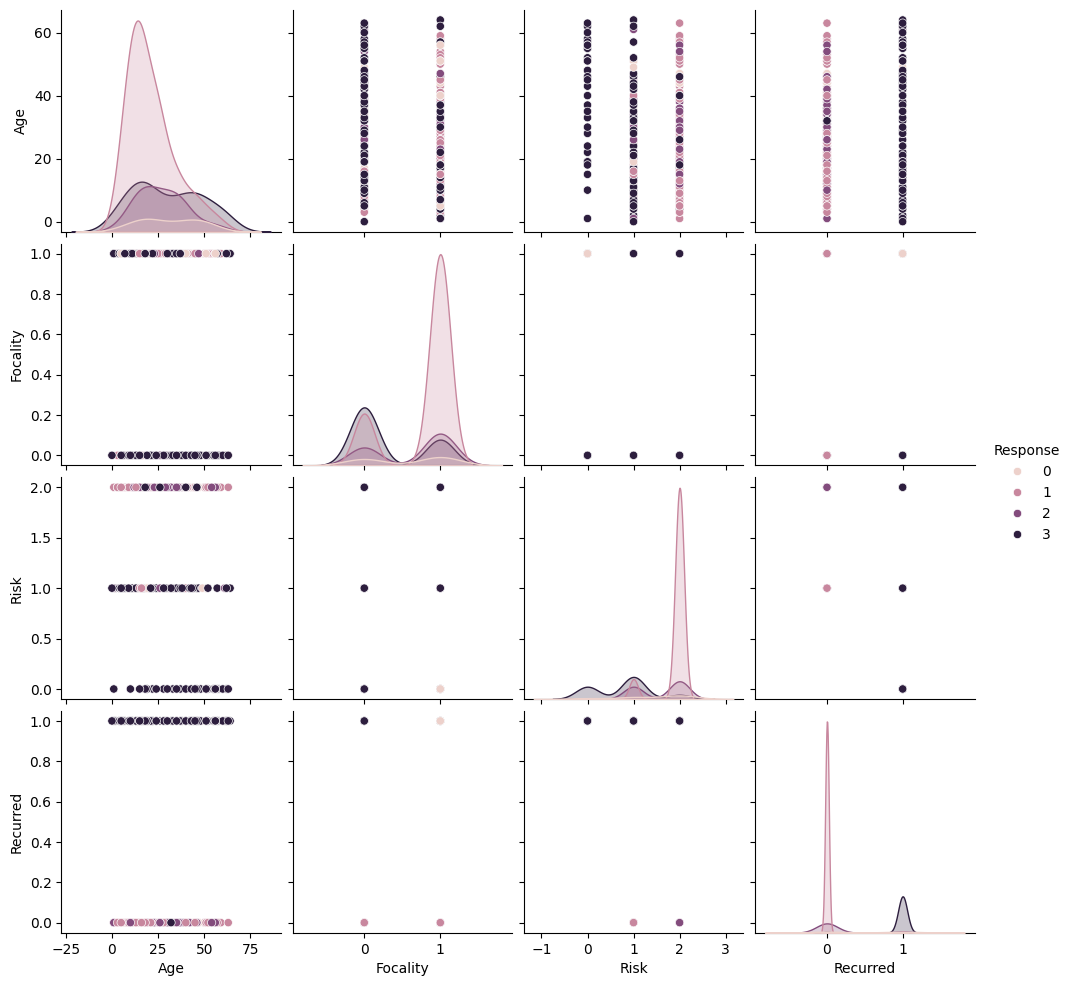

In [9]:
selections = ['Age' , 'Focality' , 'Risk', 'Response','Recurred']
sns.pairplot(data[selections],hue = 'Response')
plt.show()